# Davidson Rafael - 412024030
## Praktikum 04: Convolutional Neural Networks
## Dari piksel ke peta fitur dengan PyTorch

Notebook ini mendampingi materi Minggu 4. Semua bagian utama sudah dicontohkan. Tugas mahasiswa adalah **memprediksi hasil, menjalankan kode, memeriksa keluaran, lalu menjelaskan apa yang terjadi**. Tidak ada fungsi besar yang harus ditulis dari awal.

### Target belajar

Setelah praktikum, mahasiswa dapat:

1. menjelaskan bagaimana satu kernel menghasilkan satu peta fitur;
2. menghitung bentuk keluaran konvolusi dari ukuran kernel, padding, dan stride;
3. membaca perubahan bentuk tensor pada CNN sederhana;
4. menjalankan pelatihan CNN pada FashionMNIST; dan
5. membedakan filter terlatih dari peta aktivasi suatu citra.

### Alokasi waktu

| Bagian | Kegiatan | Waktu |
|---|---|---:|
| A | Operasi kernel dan peta fitur | 10 menit |
| B | Bentuk keluaran konvolusi | 8 menit |
| C | Arsitektur SmallCNN dan parameter | 10 menit |
| D | Pelatihan dan pengamatan aktivasi | 17 menit |
| E | Refleksi dan pengumpulan | 5 menit |

> **Cara memakai notebook:** jalankan sel secara berurutan. Isi bagian berlabel **Latihan** sebelum melihat hasil dari sel pemeriksa. Di Google Colab, gunakan menu **File > Save a copy in Drive** agar jawaban tersimpan.

## 0. Persiapan

Google Colab sudah menyediakan PyTorch, Torchvision, dan Matplotlib. Sel berikut menyiapkan pustaka, bilangan acak, serta perangkat komputasi. GPU boleh digunakan, tetapi praktikum ini tetap dapat berjalan pada CPU.

In [2]:
import random
import numpy as np
import matplotlib.pyplot as plt
import torch
import torch.nn.functional as F
from torch import nn
from torch.utils.data import DataLoader, Subset
from torchvision import datasets, transforms

SEED = 42
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)
if torch.cuda.is_available():
    torch.cuda.manual_seed_all(SEED)

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("PyTorch  :", torch.__version__)
print("Perangkat:", device)

PyTorch  : 2.11.0+cu128
Perangkat: cuda


---
## Bagian A: Dari satu kernel menjadi peta fitur

PyTorch memakai operasi *cross-correlation*. Kernel tidak dibalik. Pada setiap posisi, potongan input dan kernel dikalikan elemen demi elemen, kemudian seluruh hasilnya dijumlahkan.

Contoh dari materi kelas menggunakan potongan input dan kernel berikut:

$$X = \begin{bmatrix}0&0&1\\0&0&1\\0&0&1\end{bmatrix}, \qquad K = \begin{bmatrix}-1&0&1\\-1&0&1\\-1&0&1\end{bmatrix}$$

Hasil perkalian dan penjumlahannya adalah 3. Nilai positif besar muncul karena pola input searah dengan kernel.

In [3]:
patch = torch.tensor([[0., 0., 1.],
                      [0., 0., 1.],
                      [0., 0., 1.]])
kernel = torch.tensor([[-1., 0., 1.],
                       [-1., 0., 1.],
                       [-1., 0., 1.]])

perkalian = patch * kernel
nilai_manual = perkalian.sum().item()
nilai_pytorch = F.conv2d(
    patch.view(1, 1, 3, 3),
    kernel.view(1, 1, 3, 3)
).item()

print("Perkalian elemen demi elemen:\n", perkalian)
print("Hasil manual :", nilai_manual)
print("Hasil PyTorch:", nilai_pytorch)
assert nilai_manual == nilai_pytorch == 3.0

Perkalian elemen demi elemen:
 tensor([[-0., 0., 1.],
        [-0., 0., 1.],
        [-0., 0., 1.]])
Hasil manual : 3.0
Hasil PyTorch: 3.0


### Latihan 1: Balik arah polanya

Kolom bernilai 1 sekarang dipindahkan ke sisi kiri. Sebelum menjalankan sel pemeriksa, tuliskan prediksi berikut pada catatan atau langsung ubah nilai variabel di bawah.

- Apakah keluarannya positif, nol, atau negatif?
- Berapa nilainya?

Latihan ini sama dengan contoh yang baru dihitung. Perbedaannya hanya posisi kolom terang.

In [4]:
# Isi jika ingin menyimpan prediksi di notebook.
prediksi_tanda = "negatif"       # contoh isi: "positif", "nol", atau "negatif"
prediksi_nilai = -3     # contoh isi: 3

patch_balik = torch.tensor([[1., 0., 0.],
                            [1., 0., 0.],
                            [1., 0., 0.]])
hasil_balik = F.conv2d(
    patch_balik.view(1, 1, 3, 3),
    kernel.view(1, 1, 3, 3)
).item()

print("Prediksi tanda:", prediksi_tanda or "belum diisi")
print("Prediksi nilai:", prediksi_nilai if prediksi_nilai is not None else "belum diisi")
print("Hasil aktual  :", hasil_balik)
print("Makna         : pola berlawanan arah menghasilkan respons dengan tanda berlawanan.")

Prediksi tanda: negatif
Prediksi nilai: -3
Hasil aktual  : -3.0
Makna         : pola berlawanan arah menghasilkan respons dengan tanda berlawanan.


Pas kolom `1` dipindahin dari kanan ke kiri hasil konvulasinya berubah dari +3 jadi -3 karena nilai 1 sekarang ketemu dengan bobot -1 pada kernel

$$
\begin{bmatrix}
1 & 0 & 0 \\
1 & 0 & 0 \\
1 & 0 & 0
\end{bmatrix}
\odot
\begin{bmatrix}
-1 & 0 & 1 \\
-1 & 0 & 1 \\
-1 & 0 & 1
\end{bmatrix}
=
\begin{bmatrix}
-1 & 0 & 0 \\
-1 & 0 & 0 \\
-1 & 0 & 0
\end{bmatrix}
$$

$$
\text{Patch}
\qquad\qquad
\text{Kernel}
\qquad\qquad
\text{Hasil perkalian}
$$

$$
(-1) + (-1) + (-1) = \boxed{-3}
$$

### Kernel yang sama digeser ke seluruh citra

Satu posisi menghasilkan satu angka. Ketika kernel yang sama digeser ke semua posisi valid, kumpulan angkanya menjadi satu peta fitur. Karena input berukuran $5 \times 5$ dan kernel berukuran $3 \times 3$ tanpa padding, peta fitur berukuran $3 \times 3$.

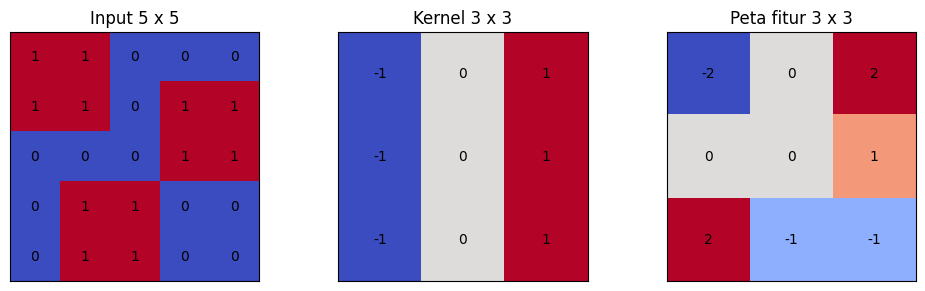

tensor([[-2.,  0.,  2.],
        [ 0.,  0.,  1.],
        [ 2., -1., -1.]])


In [5]:
citra_kecil = torch.tensor([
    [1., 1., 0., 0., 0.],
    [1., 1., 0., 1., 1.],
    [0., 0., 0., 1., 1.],
    [0., 1., 1., 0., 0.],
    [0., 1., 1., 0., 0.]
])

peta_fitur = F.conv2d(
    citra_kecil.view(1, 1, 5, 5),
    kernel.view(1, 1, 3, 3)
)[0, 0]

fig, axes = plt.subplots(1, 3, figsize=(10, 3))
for ax, data, judul in zip(
    axes,
    [citra_kecil, kernel, peta_fitur],
    ["Input 5 x 5", "Kernel 3 x 3", "Peta fitur 3 x 3"]
):
    ax.imshow(data, cmap="coolwarm")
    for baris in range(data.shape[0]):
        for kolom in range(data.shape[1]):
            ax.text(kolom, baris, f"{data[baris, kolom].item():.0f}",
                    ha="center", va="center", color="black")
    ax.set_title(judul)
    ax.set_xticks([])
    ax.set_yticks([])
plt.tight_layout()
plt.show()

print(peta_fitur)
assert tuple(peta_fitur.shape) == (3, 3)

---
## Bagian B: Menghitung bentuk keluaran

Untuk satu dimensi spasial, ukuran keluaran konvolusi dihitung dengan:

$$H_{out}=\left\lfloor\frac{H_{in}+2P-D(K-1)-1}{S}\right\rfloor+1$$

Keterangan: $K$ adalah ukuran kernel, $P$ adalah padding, $S$ adalah stride, dan $D$ adalah dilation. Rumus yang sama dipakai untuk lebar.

In [6]:
def ukuran_keluaran(n_in, kernel_size, padding=0, stride=1, dilation=1):
    return ((n_in + 2 * padding - dilation * (kernel_size - 1) - 1) // stride) + 1

contoh = ukuran_keluaran(n_in=28, kernel_size=3, padding=1, stride=1)
print("Input 28, kernel 3, padding 1, stride 1 menghasilkan ukuran", contoh)
assert contoh == 28

Input 28, kernel 3, padding 1, stride 1 menghasilkan ukuran 28


### Latihan 2: Prediksi sebelum menjalankan

Hitung tiga kasus berikut dengan rumus pada materi. Setelah itu jalankan sel pemeriksa.

1. Input 28, kernel 3, padding 0, stride 1.
2. Input 28, kernel 3, padding 1, stride 2.
3. Input 14, kernel 5, padding 2, stride 1.

Tuliskan prediksi pada daftar `prediksi_ukuran`. Isian `None` tidak menyebabkan notebook berhenti, tetapi sebaiknya diganti sebelum hasil aktual dilihat.

In [8]:
prediksi_ukuran = [26, 14, 14]  # ganti dengan tiga hasil hitungan

kasus = [
    dict(n_in=28, kernel_size=3, padding=0, stride=1),
    dict(n_in=28, kernel_size=3, padding=1, stride=2),
    dict(n_in=14, kernel_size=5, padding=2, stride=1),
]
hasil_aktual = [ukuran_keluaran(**item) for item in kasus]

for nomor, (prediksi, aktual) in enumerate(zip(prediksi_ukuran, hasil_aktual), start=1):
    status = "belum diisi" if prediksi is None else ("benar" if prediksi == aktual else "periksa lagi")
    print(f"Kasus {nomor}: prediksi={prediksi}, aktual={aktual}, status={status}")

Kasus 1: prediksi=26, aktual=26, status=benar
Kasus 2: prediksi=14, aktual=14, status=benar
Kasus 3: prediksi=14, aktual=14, status=benar


---
## Bagian C: SmallCNN

Arsitektur yang dipakai sama dengan modul:

`Input 1 x 28 x 28 -> Conv(1,8) -> ReLU -> Pool -> Conv(8,16) -> ReLU -> Pool -> Flatten -> Linear(784,10)`

Kode model sudah lengkap. Sebelum menjalankan sel pemeriksa bentuk, prediksi bentuk tensor setelah setiap tahap pada catatan praktikum.

In [9]:
class SmallCNN(nn.Module):
    def __init__(self):
        super().__init__()
        self.features = nn.Sequential(
            nn.Conv2d(1, 8, kernel_size=3, padding=1),
            nn.ReLU(),
            nn.MaxPool2d(kernel_size=2),
            nn.Conv2d(8, 16, kernel_size=3, padding=1),
            nn.ReLU(),
            nn.MaxPool2d(kernel_size=2),
        )
        self.classifier = nn.Linear(16 * 7 * 7, 10)

    def forward(self, x):
        x = self.features(x)
        x = torch.flatten(x, start_dim=1)
        return self.classifier(x)

model = SmallCNN().to(device)
print(model)

SmallCNN(
  (features): Sequential(
    (0): Conv2d(1, 8, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (1): ReLU()
    (2): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    (3): Conv2d(8, 16, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (4): ReLU()
    (5): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  )
  (classifier): Linear(in_features=784, out_features=10, bias=True)
)


### Latihan 3: Bentuk tensor dan jumlah parameter

Lengkapi tabel berikut dengan prediksi terlebih dahulu. Setelah itu jalankan sel di bawah untuk membandingkan prediksi dengan hasil PyTorch.

| Tahap | Prediksi bentuk tanpa batch |
|---|---|
| Input | `1 x 28 x 28` |
| Conv1 + ReLU | `8 x 28 x 28` |
| Pool1 | `8 x 14 x 14` |
| Conv2 + ReLU | `8 x 14 x 14` |
| Pool2 | `16 x 7 x 7` |
| Flatten | `784` |
| Linear | `10` |

Untuk parameter, gunakan rumus $C_{out}(C_{in}K_hK_w+1)$. Angka 1 mewakili bias untuk setiap filter.

In [10]:
# Isi bentuk tanpa dimensi batch sebelum menjalankan sel pemeriksa berikutnya.
# Contoh penulisan: (8, 28, 28)
prediksi_bentuk = {
    "Conv1 + ReLU": (8, 28, 28),
    "Pool1": (8, 14, 14),
    "Conv2 + ReLU": (16, 14, 14),
    "Pool2": (16, 7, 7),
    "Flatten": (784,),
    "Linear": (10,),
}
print("Prediksi tersimpan. Jalankan sel berikut untuk memeriksa.")

Prediksi tersimpan. Jalankan sel berikut untuk memeriksa.


In [11]:
x = torch.zeros(1, 1, 28, 28, device=device)
nama_tahap = ["Conv1", "ReLU1", "Pool1", "Conv2", "ReLU2", "Pool2"]

print(f"{'Tahap':<10} {'Bentuk output':<22} {'Parameter':>10}")
print("-" * 46)
print(f"{'Input':<10} {str(tuple(x.shape)):<22} {0:>10}")

with torch.no_grad():
    for nama, lapisan in zip(nama_tahap, model.features):
        x = lapisan(x)
        jumlah_parameter = sum(p.numel() for p in lapisan.parameters())
        print(f"{nama:<10} {str(tuple(x.shape)):<22} {jumlah_parameter:>10,}")
    bentuk_sebelum_flatten = tuple(x.shape)
    x = torch.flatten(x, start_dim=1)
    print(f"{'Flatten':<10} {str(tuple(x.shape)):<22} {0:>10}")
    logits = model.classifier(x)
    parameter_linear = sum(p.numel() for p in model.classifier.parameters())
    print(f"{'Linear':<10} {str(tuple(logits.shape)):<22} {parameter_linear:>10,}")

total_parameter = sum(p.numel() for p in model.parameters())
print("\nTotal parameter:", f"{total_parameter:,}")
assert bentuk_sebelum_flatten == (1, 16, 7, 7)
assert tuple(logits.shape) == (1, 10)
assert total_parameter == 9098

bentuk_aktual = {
    "Conv1 + ReLU": (8, 28, 28),
    "Pool1": (8, 14, 14),
    "Conv2 + ReLU": (16, 14, 14),
    "Pool2": (16, 7, 7),
    "Flatten": (784,),
    "Linear": (10,),
}
print("\nPemeriksaan prediksi bentuk:")
for tahap, aktual in bentuk_aktual.items():
    prediksi = prediksi_bentuk[tahap]
    status = "belum diisi" if prediksi is None else ("benar" if tuple(prediksi) == aktual else "periksa lagi")
    print(f"{tahap:<16} prediksi={str(prediksi):<15} aktual={str(aktual):<15} {status}")

Tahap      Bentuk output           Parameter
----------------------------------------------
Input      (1, 1, 28, 28)                  0
Conv1      (1, 8, 28, 28)                 80
ReLU1      (1, 8, 28, 28)                  0
Pool1      (1, 8, 14, 14)                  0
Conv2      (1, 16, 14, 14)             1,168
ReLU2      (1, 16, 14, 14)                 0
Pool2      (1, 16, 7, 7)                   0
Flatten    (1, 784)                        0
Linear     (1, 10)                     7,850

Total parameter: 9,098

Pemeriksaan prediksi bentuk:
Conv1 + ReLU     prediksi=(8, 28, 28)     aktual=(8, 28, 28)     benar
Pool1            prediksi=(8, 14, 14)     aktual=(8, 14, 14)     benar
Conv2 + ReLU     prediksi=(16, 14, 14)    aktual=(16, 14, 14)    benar
Pool2            prediksi=(16, 7, 7)      aktual=(16, 7, 7)      benar
Flatten          prediksi=(784,)          aktual=(784,)          benar
Linear           prediksi=(10,)           aktual=(10,)           benar


---
## Bagian D: FashionMNIST dan pelatihan CNN

FashionMNIST berisi citra abu-abu berukuran $28 \times 28$ dari sepuluh kelas pakaian. Subset 2.000 citra digunakan untuk pelatihan dan 500 citra lain untuk validasi. Ukuran ini cukup untuk melihat alur belajar tanpa menunggu lama.

Data akan diunduh otomatis pada pemakaian pertama. Setelah tersimpan, data yang sama dapat dipakai kembali.

In [12]:
class_names = [
    "T-shirt/top", "Trouser", "Pullover", "Dress", "Coat",
    "Sandal", "Shirt", "Sneaker", "Bag", "Ankle boot"
]

transform = transforms.ToTensor()
full_data = datasets.FashionMNIST(
    root="data",
    train=True,
    download=True,
    transform=transform,
)

generator = torch.Generator().manual_seed(SEED)
urutan = torch.randperm(len(full_data), generator=generator)
train_data = Subset(full_data, urutan[:2000].tolist())
val_data = Subset(full_data, urutan[2000:2500].tolist())

train_loader = DataLoader(train_data, batch_size=64, shuffle=True, num_workers=0)
val_loader = DataLoader(val_data, batch_size=128, shuffle=False, num_workers=0)

images, labels = next(iter(train_loader))
print("Bentuk batch gambar:", tuple(images.shape))
print("Bentuk batch label :", tuple(labels.shape))
print("Rentang piksel     :", images.min().item(), "sampai", images.max().item())

100%|██████████| 26.4M/26.4M [00:02<00:00, 11.3MB/s]
100%|██████████| 29.5k/29.5k [00:00<00:00, 165kB/s]
100%|██████████| 4.42M/4.42M [00:01<00:00, 3.17MB/s]
100%|██████████| 5.15k/5.15k [00:00<00:00, 24.9MB/s]

Bentuk batch gambar: (64, 1, 28, 28)
Bentuk batch label : (64,)
Rentang piksel     : 0.0 sampai 1.0


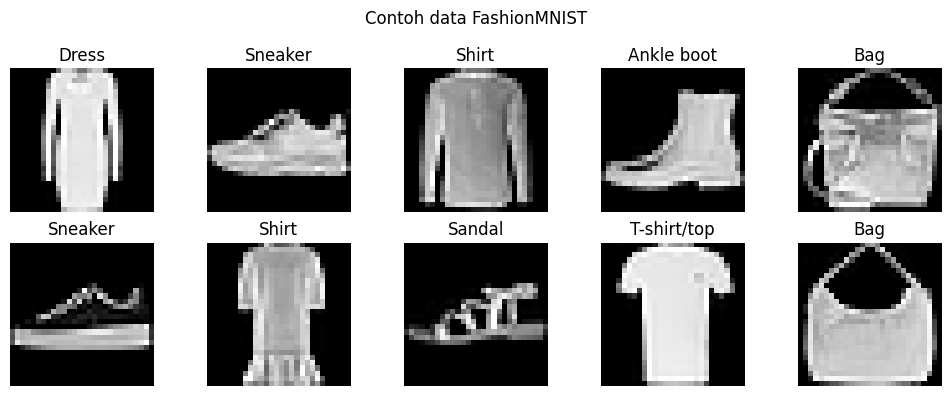

In [13]:
fig, axes = plt.subplots(2, 5, figsize=(10, 4))
for i, ax in enumerate(axes.flat):
    ax.imshow(images[i, 0], cmap="gray")
    ax.set_title(class_names[labels[i].item()])
    ax.axis("off")
plt.suptitle("Contoh data FashionMNIST")
plt.tight_layout()
plt.show()

### Pelatihan dua epoch

Urutan pelatihan sama dengan Minggu 3: hapus gradien lama, lakukan *forward pass*, hitung *loss*, jalankan *backpropagation*, lalu perbarui bobot. Yang berubah hanya arsitektur modelnya.

Catat nilai *loss* epoch pertama dan kedua. *Loss* per *batch* dapat naik turun. Yang diamati adalah kecenderungan rata-rata per epoch, bukan tuntutan agar setiap langkah selalu turun.

In [14]:
def train_one_epoch(model, loader, loss_fn, optimizer, device):
    model.train()
    total_loss = 0.0
    benar = 0
    total = 0

    for images, labels in loader:
        images = images.to(device)
        labels = labels.to(device)

        optimizer.zero_grad()
        logits = model(images)
        loss = loss_fn(logits, labels)
        loss.backward()
        optimizer.step()

        total_loss += loss.item() * images.size(0)
        benar += (logits.argmax(dim=1) == labels).sum().item()
        total += images.size(0)

    return total_loss / total, 100 * benar / total

def evaluate(model, loader, loss_fn, device):
    model.eval()
    total_loss = 0.0
    benar = 0
    total = 0

    with torch.no_grad():
        for images, labels in loader:
            images = images.to(device)
            labels = labels.to(device)
            logits = model(images)
            loss = loss_fn(logits, labels)
            total_loss += loss.item() * images.size(0)
            benar += (logits.argmax(dim=1) == labels).sum().item()
            total += images.size(0)

    return total_loss / total, 100 * benar / total

In [18]:
model = SmallCNN().to(device)
loss_fn = nn.CrossEntropyLoss()
optimizer = torch.optim.Adam(model.parameters(), lr=1e-3)
history = []

for epoch in range(1, 3):
    train_loss, train_acc = train_one_epoch(model, train_loader, loss_fn, optimizer, device)
    val_loss, val_acc = evaluate(model, val_loader, loss_fn, device)
    history.append({
        "epoch": epoch,
        "train_loss": train_loss,
        "train_acc": train_acc,
        "val_loss": val_loss,
        "val_acc": val_acc,
    })
    print(
        f"Epoch {epoch}: "
        f"train loss={train_loss:.4f}, train acc={train_acc:.1f}% | "
        f"val loss={val_loss:.4f}, val acc={val_acc:.1f}%"
    )

print("\nCatatan pengumpulan")
print("Loss awal :", round(history[0]["train_loss"], 4))
print("Loss akhir:", round(history[-1]["train_loss"], 4))

Epoch 1: train loss=2.0717, train acc=35.2% | val loss=1.6331, val acc=49.2%
Epoch 2: train loss=1.2098, train acc=59.9% | val loss=0.8918, val acc=66.4%

Catatan pengumpulan
Loss awal : 2.0717
Loss akhir: 1.2098


### Prediksi pada data validasi

Citra validasi tidak digunakan untuk memperbarui bobot. Warna judul hijau berarti prediksi benar, sedangkan merah berarti prediksi berbeda dari label. Tidak ada target nilai minimum tertentu pada latihan ini. Hal yang dinilai adalah alur kerja dan penjelasan mahasiswa.

Akurasi batch validasi: 67.2%


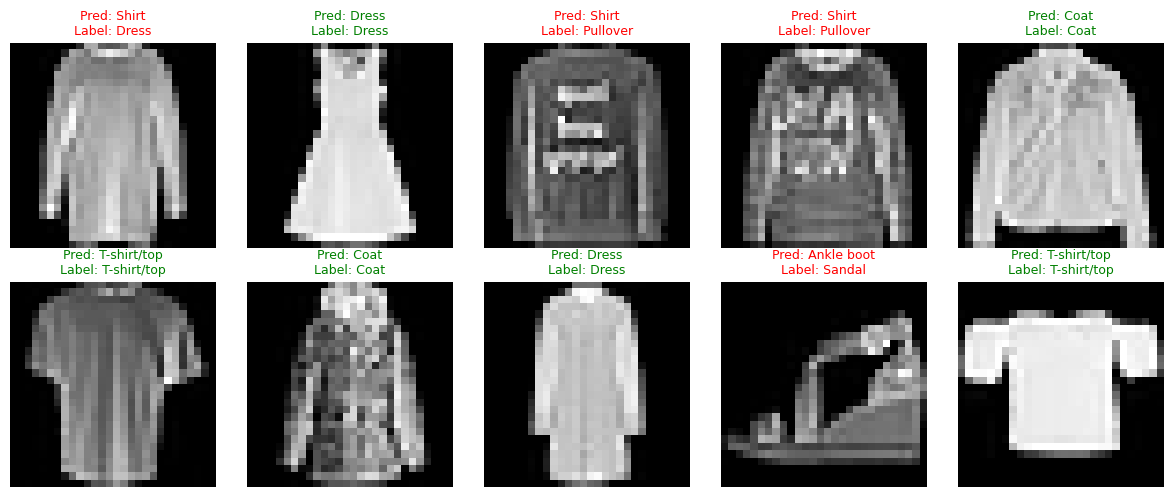

In [19]:
model.eval()
with torch.no_grad():
    val_images, val_labels = next(iter(val_loader))
    val_logits = model(val_images.to(device))
    val_pred = val_logits.argmax(dim=1).cpu()

akurasi_batch = (val_pred == val_labels).float().mean().item() * 100
print(f"Akurasi batch validasi: {akurasi_batch:.1f}%")

fig, axes = plt.subplots(2, 5, figsize=(12, 5))
for i, ax in enumerate(axes.flat):
    benar = val_pred[i].item() == val_labels[i].item()
    warna = "green" if benar else "red"
    ax.imshow(val_images[i, 0], cmap="gray")
    ax.set_title(
        f"Pred: {class_names[val_pred[i].item()]}\nLabel: {class_names[val_labels[i].item()]}",
        color=warna, fontsize=9
    )
    ax.axis("off")
plt.tight_layout()
plt.show()

### Peta aktivasi lapisan pertama

Conv1 memiliki delapan filter, sehingga keluarannya memiliki delapan kanal. Sel berikut menampilkan delapan peta aktivasi dari citra validasi pertama setelah `Conv1 -> ReLU -> MaxPool`.

Peta yang lebih terang menunjukkan aktivasi relatif lebih tinggi pada panel tersebut. Hal ini belum membuktikan bahwa kanal memahami objek tertentu atau bahwa area terang menjadi satu-satunya alasan prediksi model.

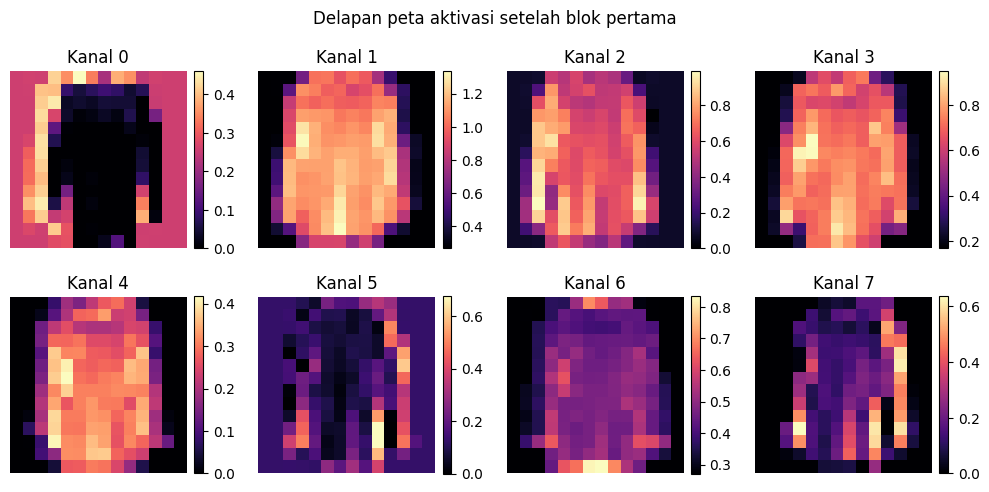

Bentuk peta aktivasi: (1, 8, 14, 14)


In [20]:
model.eval()
with torch.no_grad():
    satu_citra = val_images[:1].to(device)
    activation_maps = model.features[:3](satu_citra).cpu()

fig, axes = plt.subplots(2, 4, figsize=(10, 5))
for kanal, ax in enumerate(axes.flat):
    gambar = ax.imshow(activation_maps[0, kanal], cmap="magma")
    ax.set_title(f"Kanal {kanal}")
    ax.axis("off")
    fig.colorbar(gambar, ax=ax, fraction=0.046, pad=0.04)
plt.suptitle("Delapan peta aktivasi setelah blok pertama")
plt.tight_layout()
plt.show()

print("Bentuk peta aktivasi:", tuple(activation_maps.shape))

---
## Bagian E: Latihan inti dan pengumpulan

Yang dikumpulkan cukup berupa notebook ini. Pastikan keluaran sel tetap tersimpan. Tidak perlu membuat laporan terpisah.

### Checklist latihan inti

- [x] Latihan 1: prediksi tanda dan nilai respons kernel.
- [x] Latihan 2: tiga prediksi ukuran keluaran.
- [x] Latihan 3: tabel bentuk tensor SmallCNN.
- [x] Catat *loss* epoch pertama dan kedua.
- [x] Simpan keluaran visualisasi peta aktivasi.
- [x] Jawab empat pertanyaan refleksi di bawah.

### Pertanyaan refleksi

Jawaban cukup dua sampai empat kalimat per pertanyaan.

1. Mengapa ukuran citra yang lebih besar tidak menambah jumlah parameter pada lapisan `Conv2d` yang sama?
2. Mengapa citra satu kanal dapat berubah menjadi delapan kanal setelah Conv1?
3. Apa yang berubah pada bentuk keluaran jika padding Conv1 diubah dari 1 menjadi 0? Tunjukkan hitungannya.
4. Apakah peta aktivasi yang terang membuktikan bahwa bagian itu menjadi alasan utama prediksi model? Jelaskan batasnya.

### Jawaban mahasiswa

**1. Berbagi bobot**

Karena jumlah parameter pada Conv2d ditentukan oleh jumlah channel input, jumlah filter, ukuran kernel, dan bias, bukan ukuran citra. Jika ukuran citra diperbesar tapi konfigurasi Conv2d tetep sama, kernel yang sama hanya akan digeser ke lebih banyak posisi sehingga jumlah parameternya tetep.

**2. Kanal keluaran**

Karena Conv1 memiliki 8 filter yang masing-masing ngehasilin 1 feature map. Walaupun citra input hanya memiliki 1 kanal, setiap filter memproses kanal tersebut untuk mencari pola yang berbeda jadi keluarannya menjadi 8 kanal.

**3. Dampak padding**

Jika padding Conv1 diubah dari 1 jadi 0, ukuran spasial output akan mengecil dari 28 x 28 jadi 26 x 26. Pake rumus ukuran output diperoleh (28 + 2(0) - 3) / 1 + 1 = 26, jadi bentuk keluaran Conv1 berubah dari 8 x 28 x 28 jadi 8 x 26 x 26.

**4. Batas interpretasi**

Tidak, bagian yang terang hanya menunjukkan bahwa suatu filter memberikan respons atau aktivasi yang kuat pada bagian tersebut. Hal ini belum membuktikan bahwa bagian itu menjadi alasan utama prediksi karena hasil akhir model juga dipengaruhi oleh aktivasi dari filter dan layer lainnya.

---
## Bonus opsional: Satu perubahan kecil

Kerjakan hanya setelah latihan inti selesai. Pilih satu perubahan berikut.

- Ubah `padding=1` menjadi `padding=0` pada Conv1.
- Ubah jumlah filter Conv1 dari 8 menjadi 16.
- Ganti `MaxPool2d` dengan `AvgPool2d`.
- Ganti FashionMNIST dengan KMNIST pada sel pemuatan data. Keduanya memiliki citra satu kanal berukuran $28 \times 28$, sehingga bentuk input model tidak perlu diubah.

Sebelum menjalankan perubahan, tuliskan prediksi tentang bentuk keluaran atau jumlah parameter. Setelah itu bandingkan dengan hasil aktual. Cukup jelaskan dalam dua kalimat. Untuk tiga perubahan arsitektur, edit **sel bantu bonus di bawah**, bukan model utama. Jika Conv1 pada model penuh diubah, ukuran `Linear` juga mungkin harus disesuaikan.

In [22]:
# Sel bantu bonus. Ubah satu nilai, lalu bandingkan hasilnya dengan Conv1 asli.
bonus_out_channels = 8
bonus_padding = 0
bonus_pool = nn.MaxPool2d(2)  # boleh diganti dengan nn.AvgPool2d(2)

bonus_block = nn.Sequential(
    nn.Conv2d(1, bonus_out_channels, kernel_size=3, padding=bonus_padding),
    nn.ReLU(),
    bonus_pool,
)

dummy = torch.zeros(1, 1, 28, 28)
bonus_output = bonus_block(dummy)
bonus_params = sum(p.numel() for p in bonus_block.parameters())
print("Bentuk output blok:", tuple(bonus_output.shape))
print("Jumlah parameter   :", bonus_params)

Bentuk output blok: (1, 8, 13, 13)
Jumlah parameter   : 80


## Penutup

Pada praktikum ini, CNN tidak diperlakukan sebagai kotak hitam. Satu operasi kernel dihitung lebih dahulu, perubahan bentuk tensor diperiksa pada setiap lapisan, lalu model dilatih pada citra nyata. Minggu berikutnya akan membahas bagaimana blok yang sama disusun menjadi arsitektur yang lebih dalam atau lebih hemat komputasi.